# Ambient Temperature -- 2026-07-05 to 2026-07-10

GHS ambient-environment data pulled from the xsphere InfluxDB bucket
(`analysis/ambient_temp_pull.py`), local (America/New_York) time. This window
covers the full laser step-down run (`laser_stepdown_settling.ipynb`,
2026-07-05 21:46 UTC -> 2026-07-09 20:05 UTC), so the step plateaus are
overlaid below -- relevant to the standing question of whether laser-heating
/ outgassing explains the step-7 anti-correlation seen in
`laser_stepdown_forward_model.ipynb` Section 6.8.

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TEMP_CSV  = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/ambient_temperature_20260705_0000_20260710_0000.csv'
STEPS_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'
GPS_UNIX_OFFSET = 315964800 - 18

## 1. Load and Overview

In [2]:
df = pd.read_csv(TEMP_CSV, parse_dates=['time'])
df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert('America/New_York')
df = df.sort_values('time').reset_index(drop=True)

print(f"{len(df)} points  {df['time'].iloc[0]} -> {df['time'].iloc[-1]}")
print(df['temperature'].describe())

720 points  2026-07-05 00:10:00-04:00 -> 2026-07-10 00:00:00-04:00
count    720.000000
mean      23.287362
std        0.259544
min       20.507629
25%       23.229137
50%       23.400000
75%       23.400000
max       23.800000
Name: temperature, dtype: float64


## 2. Full-Span Plot, with Step-Down Windows Overlaid

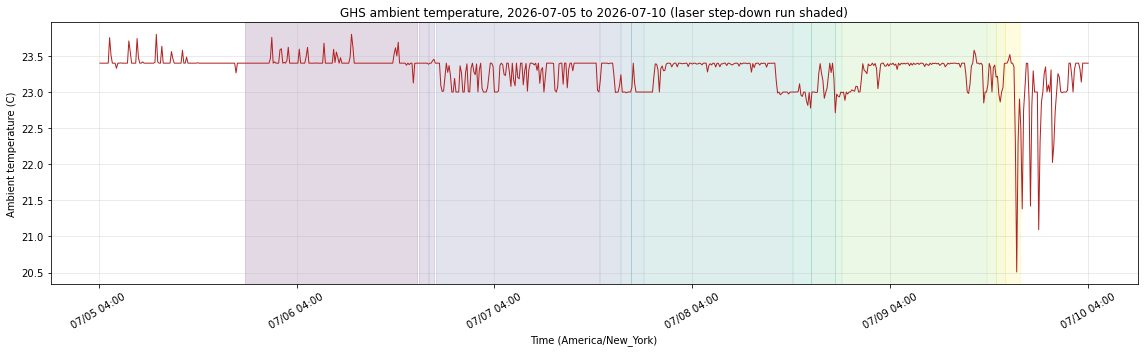

In [3]:
steps = []
with open(STEPS_CSV) as f:
    for row in csv.DictReader(f):
        steps.append(dict(step=int(row['step']), counts=row['counts'],
                          power_mw=row['power_mw'],
                          t0=pd.Timestamp(float(row['t_start_gps']) + GPS_UNIX_OFFSET, unit='s', tz='UTC'),
                          t1=pd.Timestamp(float(row['t_end_gps']) + GPS_UNIX_OFFSET, unit='s', tz='UTC')))

def step_label(s):
    if s['counts']:
        return f"{s['counts']} cts ({float(s['power_mw']):.1f} mW)" if s['power_mw'] else f"{s['counts']} cts"
    return f"step {s['step']}"

colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['time'], df['temperature'], color='firebrick', linewidth=1.0)
for i, s in enumerate(steps):
    ax.axvspan(s['t0'], s['t1'], color=colors[i], alpha=0.15)
ax.set_xlabel('Time (America/New_York)')
ax.set_ylabel('Ambient temperature (C)')
ax.set_title('GHS ambient temperature, 2026-07-05 to 2026-07-10 (laser step-down run shaded)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Per-Step Temperature: Mean and Trend
For each detected step, the ambient temperature's mean and its trend (start -> end)
over that plateau -- a slow monotonic rise/fall during a hold is the kind of signal
that would support the heating/outgassing hypothesis for step 7's anti-correlation,
if it lines up with that step specifically.

In [4]:
t_temp = df['time'].values.astype('datetime64[ns]').astype('int64') / 1e9   # unix seconds
temp = df['temperature'].values

print(f"{'step':>4} | {'level':>20} | {'mean C':>7} | {'trend (C over hold)':>19}")
for s in steps:
    t0u, t1u = s['t0'].timestamp(), s['t1'].timestamp()
    m = (t_temp >= t0u) & (t_temp <= t1u)
    if m.sum() < 2:
        continue
    trend = temp[m][-1] - temp[m][0]
    print(f"{s['step']:>4} | {step_label(s):>20} | {temp[m].mean():>7.2f} | {trend:>+19.3f}")

step |                level |  mean C | trend (C over hold)
   0 |               step 0 |   23.43 |              +0.000
   1 |               step 1 |   23.40 |              +0.000
   2 |   1800 cts (12.5 mW) |   23.42 |              +0.055
   3 |   1600 cts (10.3 mW) |   23.26 |              -0.400
   4 |    1550 cts (9.9 mW) |   23.27 |              -0.069
   5 |    1500 cts (9.2 mW) |   23.00 |              +0.000
   6 |    1400 cts (8.0 mW) |   23.06 |              -0.064
   7 |    1300 cts (6.7 mW) |   23.31 |              +0.000
   8 |    1200 cts (5.4 mW) |   22.96 |              -0.222
   9 |               step 9 |   23.15 |              +0.185
  10 |              step 10 |   22.91 |              +0.286
  11 |    1000 cts (3.0 mW) |   23.31 |              +0.009
  12 |              step 12 |   23.25 |              +0.106
  13 |              step 13 |   23.08 |              +0.176
  14 |              step 14 |   22.90 |              -0.496
